# Notebook 1: Completar outputs de pySCENIC antes de integración con Seurat

Esta libreta completa los pasos específicos de SCENIC antes de integrar los resultados con el análisis scRNA-seq generado en Seurat.

Objetivos principales:
- leer `SCENIC.loom`
- extraer la matriz de actividad de regulones (`RegulonsAUC`)
- binarizar la actividad de regulones
- calcular proyecciones no lineales en el espacio de regulones
- realizar clustering basado en regulones
- guardar todos los outputs necesarios para la integración posterior

Adaptado de:
- `SCENICprotocol` del laboratorio de Aerts
- `PBMC10k_downstream-analysis.ipynb`
- flujo general del protocolo SCENIC / pySCENIC

Esta libreta está adaptada a un dataset de HA15 vs Control en un modelo de latencia del VIH-1 con células CD4+ humanas (GSE210824).

In [42]:
import os

os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import loompy as lp
import json
import base64
import zlib
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from pathlib import Path

# Compatibilidad pyscenic con NumPy moderno
if not hasattr(np, "float"):
    np.float = float

from pyscenic.binarization import binarize

## 1. Definir rutas y archivos de entrada y funciones auxiliares

En esta fase se usa:
- `SCENIC.loom` como salida principal de pySCENIC
- `metadata.tsv` como metadatos celulares básicos de Seurat (pre-análisis)
- `reg.csv` como archivo de metadata de regulones

Todavía no se necesita `adj.tsv` (se usa luego al explorar relaciones TF-target y targets de regulones concretos).

In [2]:
BASE = Path("/root/TFM/HA15_GSE210824")
RAW  = BASE / "raw_data"
PROC = BASE / "proc_data"
RESULTS = BASE / "results"
FIGURES = RESULTS / "figures"
TABLES = RESULTS / "tables"

loom_path = PROC / "SCENIC.loom"
meta_path = RAW / "metadata.tsv"
reg_path  = PROC / "reg.csv"

## 2. Inspeccionar la estructura de `SCENIC.loom` y leer identificadores celulares, nombres de regulones y salida de AUCell

Antes de extraer nada, comprobamos:
- la forma de la matriz
- los atributos globales
- los atributos de filas
- los atributos de columnas
- las layers (vacías)

Esto confirma que el loom contiene los outputs esperados de pySCENIC.

In [3]:
with lp.connect(str(loom_path), mode="r", validate=False) as lf:
    print("Matrix shape:", lf.shape)
    print("Global attrs:", list(lf.attrs.keys()))
    print("Row attrs:", list(lf.ra.keys()))
    print("Column attrs:", list(lf.ca.keys()))
    print("Layers:", list(lf.layers.keys()))

Matrix shape: (20441, 5312)
Global attrs: ['CreationDate', 'Genome', 'LOOM_SPEC_VERSION', 'MetaData', 'RVersion', 'title']
Row attrs: ['Gene', 'Regulons']
Column attrs: ['CellID', 'RegulonsAUC', 'nGene', 'nUMI']
Layers: ['']


Ahora extraemos:
- `CellID`
- los nombres brutos de los regulones
- el campo estructurado `RegulonsAUC`

Este es el punto de partida para construir la matriz de actividad de regulones.

In [4]:
with lp.connect(str(loom_path), mode="r", validate=False) as lf:
    cell_ids = np.asarray(lf.ca.CellID).astype(str).tolist()
    auc_raw = np.asarray(lf.ca.RegulonsAUC)
    regulons_raw = list(auc_raw.dtype.names) if auc_raw.dtype.names is not None else []

print("n_cells:", len(cell_ids))
print("n_regulons_raw:", len(regulons_raw))
print("auc dtype:", auc_raw.dtype)

n_cells: 5312
n_regulons_raw: 276
auc dtype: [('AHR(+)', '<f8'), ('ARID3A(+)', '<f8'), ('ARNT(+)', '<f8'), ('ARNTL2(+)', '<f8'), ('ASCL1(+)', '<f8'), ('ATF1(+)', '<f8'), ('ATF3(+)', '<f8'), ('ATF4(+)', '<f8'), ('ATF6(+)', '<f8'), ('ATF6B(+)', '<f8'), ('BACH1(+)', '<f8'), ('BACH2(+)', '<f8'), ('BATF(+)', '<f8'), ('BATF3(+)', '<f8'), ('BCL3(+)', '<f8'), ('BCLAF1(+)', '<f8'), ('BHLHE40(+)', '<f8'), ('BPTF(+)', '<f8'), ('BRCA1(+)', '<f8'), ('BRF1(+)', '<f8'), ('BRF2(+)', '<f8'), ('CEBPA(+)', '<f8'), ('CEBPB(+)', '<f8'), ('CEBPD(+)', '<f8'), ('CEBPG(+)', '<f8'), ('CEBPZ(+)', '<f8'), ('CHD2(+)', '<f8'), ('CLOCK(+)', '<f8'), ('CREB1(+)', '<f8'), ('CREB3(+)', '<f8'), ('CREB3L2(+)', '<f8'), ('CREB3L4(+)', '<f8'), ('CREBL2(+)', '<f8'), ('CREM(+)', '<f8'), ('CTCF(+)', '<f8'), ('CUX1(+)', '<f8'), ('DBP(+)', '<f8'), ('DDIT3(+)', '<f8'), ('E2F1(+)', '<f8'), ('E2F2(+)', '<f8'), ('E2F3(+)', '<f8'), ('E2F4(+)', '<f8'), ('E2F5(+)', '<f8'), ('E2F6(+)', '<f8'), ('E2F7(+)', '<f8'), ('E2F8(+)', '<f8'), ('EG

## 3. Construir la matriz continua de actividad de regulones (AUC) y QC

Aquí convertimos la salida de AUCell en una matriz estándar con:
- filas = células
- columnas = regulones

Esta matriz continua de AUC será la base para:
- la binarización
- UMAP
- t-SNE
- clustering en el espacio de regulones

In [5]:
auc_df = pd.DataFrame(auc_raw, index=cell_ids)
auc_df.index.name = "CellID"

auc_df.to_csv(PROC / "01_regulonsAUC_matrix.tsv", sep="\t")
auc_df.iloc[:5, 12:19]

,BATF(+),BATF3(+),BCL3(+),BCLAF1(+),BHLHE40(+),BPTF(+),BRCA1(+)
CellID,,,,,,,
CACCAAAAGCCGATCT,0.191012,0.132209,0.013393,0.066938,0.050258,0.039481,0.072998
CTAGACAAGCTACCGT,0.119199,0.053145,0.015391,0.060841,0.044914,0.024507,0.066980
GTAATCGAGCGATTAG,0.228054,0.114539,0.042115,0.054973,0.047842,0.037419,0.063665
ATAGACCCACCAGCCA,0.211944,0.111047,0.024176,0.060837,0.048966,0.042428,0.063438
ATCGTCCTCATTGACA,0.181751,0.082537,0.033187,0.061878,0.048010,0.034081,0.065552




Verificamos que:
- no haya células duplicadas
- no haya regulones duplicados
- no haya valores perdidos
- los valores de AUC estén dentro de un rango plausible

In [6]:
print("Duplicated cells:", auc_df.index.duplicated().sum())
print("Duplicated regulons:", auc_df.columns.duplicated().sum())
print("Any NA:", auc_df.isna().any().any())
print("AUCell matrix shape:", auc_df.shape)
print("Min AUC:", round(auc_df.values.min(), 6))
print("Max AUC:", round(auc_df.values.max(), 6))
print("Mean AUC:", round(auc_df.values.mean(), 6))
print("Median AUC:", round(np.median(auc_df.values), 6))
print("SD AUC:", round(auc_df.values.std(), 6))

Duplicated cells: 0
Duplicated regulons: 0
Any NA: False
AUCell matrix shape: (5312, 276)
Min AUC: 0.0
Max AUC: 0.766879
Mean AUC: 0.040577
Median AUC: 0.034745
SD AUC: 0.039379


In [7]:
# regulones con mayor AUC individual
auc_df.shape
auc_df.min().min()
auc_df.max().max()
auc_df.max().sort_values(ascending=False).head(10)

PPARG(+)     0.766879
SOX13(+)     0.631849
FOXP1(+)     0.599967
XBP1(+)      0.578697
ZNF554(+)    0.564401
JDP2(+)      0.554795
BATF(+)      0.539558
ZNF418(+)    0.520059
IRF5(+)      0.467466
HOXC6(+)     0.466732
dtype: float64

- QC de AUCell medio a nivel de regulón

In [8]:
auc_per_regulon = pd.DataFrame({
    "mean_auc": auc_df.mean(axis=0),
    "median_auc": auc_df.median(axis=0),
    "sd_auc": auc_df.std(axis=0),
    "min_auc": auc_df.min(axis=0),
    "max_auc": auc_df.max(axis=0)
})

auc_per_regulon.head()

,mean_auc,median_auc,sd_auc,min_auc,max_auc
AHR(+),0.034005,0.030969,0.026196,0.000000,0.164922
ARID3A(+),0.006227,0.002379,0.008328,0.000000,0.078122
ARNT(+),0.152660,0.124572,0.040647,0.005015,0.353963
ARNTL2(+),0.014504,0.000000,0.032185,0.000000,0.244455
ASCL1(+),0.001484,0.000000,0.009294,0.000000,0.133725


In [9]:
print("Min mean AUC:", round(auc_df.mean(axis=0).values.min(), 6))
print("Max mean AUC:", round(auc_df.mean(axis=0).max(), 6))

Min mean AUC: 0.001363
Max mean AUC: 0.206866


In [10]:
auc_df.mean(axis=0).sort_values(ascending=False).head(10)

XBP1(+)      0.206866
BATF(+)      0.194210
TCF4(+)      0.157743
ARNT(+)      0.152660
IRF5(+)      0.147042
ZBTB16(+)    0.121303
TLX2(+)      0.119856
GATA3(+)     0.119041
ATF6B(+)     0.116220
IRF2(+)      0.115549
dtype: float64

- lista total de regulones a partir de la matriz AUC

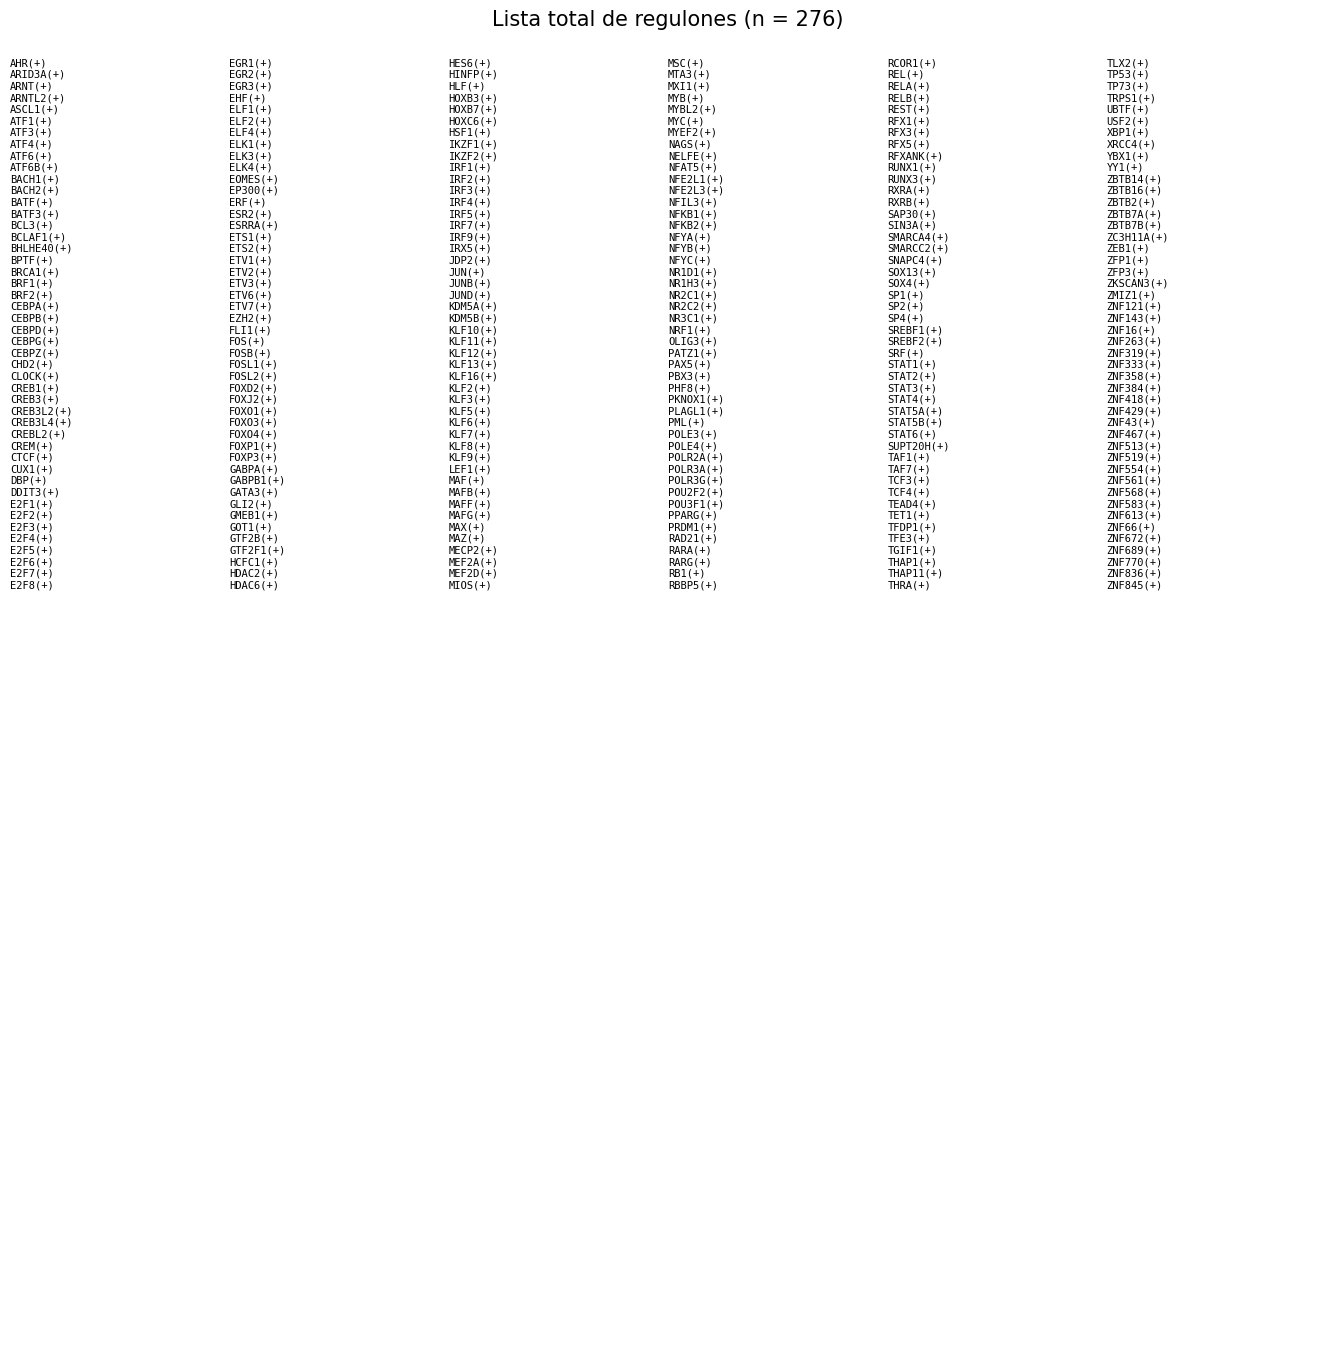

In [11]:
# Lista total de regulones a partir de la matriz AUC
regulon_list = pd.DataFrame({"Regulon": sorted(auc_df.columns)})

# Guardar tabla
regulon_list.to_csv(TABLES / "01_lista_total_regulones.tsv", sep="\t", index=False)

# Figura simple en columnas
regs = regulon_list["Regulon"].tolist()
n_cols = 6
chunk_size = int(np.ceil(len(regs) / n_cols))
fig_h = max(8, chunk_size * 0.30)
fig, axes = plt.subplots(1, n_cols, figsize=(14, fig_h))

for i, ax in enumerate(axes):
    sub_regs = regs[i * chunk_size:(i + 1) * chunk_size]
    ax.axis("off")
    ax.text(
        0, 1, "\n".join(sub_regs),
        va="top", ha="left",
        fontsize=7.5,
        family="monospace"
    )

fig.suptitle(f"Lista total de regulones (n = {len(regs)})", fontsize=15, y=0.995)
plt.subplots_adjust(left=0.03, right=0.97, top=0.96, bottom=0.02, wspace=0.00)
fig.savefig(FIGURES / "01_lista_total_regulones.png", dpi=300, bbox_inches="tight")

plt.show()

## 4. Leer y alinear los metadatos celulares básicos

Ahora leemos `metadata.tsv` y lo alineamos con la matriz AUC usando `CellID`.

Así obtenemos una tabla de metadatos sincronizada con la matriz de actividad de regulones.

In [12]:
meta_df = pd.read_csv(meta_path, sep="\t", index_col=0)
meta_df.index = meta_df.index.astype(str)
meta_df.index.name = "CellID"

common = auc_df.index.intersection(meta_df.index)

auc_df = auc_df.loc[common].copy()
meta_df = meta_df.loc[common].copy()

print("Common cells:", len(common))
print("auc_df shape:", auc_df.shape)
print("meta_df shape:", meta_df.shape)
print("Identical order:", auc_df.index.equals(meta_df.index))

meta_df.head()

Common cells: 5312
auc_df shape: (5312, 276)
meta_df shape: (5312, 18)
Identical order: True


,orig.ident,nCount_RNA,nFeature_RNA,nCount_HTO,nFeature_HTO,HTO_maxID,HTO_secondID,HTO_margin,HTO_classification,HTO_classification.global,hash.ID,Sample,Treatment,Replicate,percent.mt,percent.ribo,miQC.probability,miQC.keep
CellID,,,,,,,,,,,,,,,,,,
CACCAAAAGCCGATCT,SeuratProject,71801,7446,6005,9,Hashtag-1,Hashtag-9,5.048565,Hashtag-1,Singlet,Hashtag-1,Control_Rep1,Control,Rep1,6.566761,17.335413,4.352975e-08,keep
CTAGACAAGCTACCGT,SeuratProject,69326,7227,5551,9,Hashtag-1,Hashtag-4,5.466845,Hashtag-1,Singlet,Hashtag-1,Control_Rep1,Control,Rep1,6.043908,17.052765,2.358893e-07,keep
GTAATCGAGCGATTAG,SeuratProject,74463,7530,6469,7,Hashtag-1,Hashtag-4,5.640338,Hashtag-1,Singlet,Hashtag-1,Control_Rep1,Control,Rep1,8.862119,16.726428,1.079678e-08,keep
ATAGACCCACCAGCCA,SeuratProject,58891,7114,9648,8,Hashtag-3,Hashtag-9,5.744484,Hashtag-3,Singlet,Hashtag-3,Control_Rep3,Control,Rep3,8.204989,16.929582,1.648089e-07,keep
ATCGTCCTCATTGACA,SeuratProject,55137,6695,7121,8,Hashtag-4,Hashtag-5,4.651927,Hashtag-4,Singlet,Hashtag-4,HA15_Rep1,HA15,Rep1,9.719426,15.826033,1.392724e-06,keep


## 5. QC de la binarización de regulones

Este paso revisa los estados `on/off` de los regulones.
Durante el paso AUCell (cuando el input y el output son archivos .loom), pySCENIC binariza la actividad continua de los regulones mediante thresholds.
La representación binaria es útil después en la interpretación biológica.

Conservamos ambas representaciones:
- matriz continua de AUC
- matriz binaria de actividad de regulones

Antes de nada, tenemos que descomprimir el diccionario MetaData codificado en base64 en el archivo loom para acceder a la lista regulonThresholds:

In [13]:
with lp.connect(str(loom_path), mode="r", validate=False) as lf: md = lf.attrs["MetaData"]
if isinstance(md, bytes): md = md.decode("utf-8")

metadata = json.loads(zlib.decompress(base64.b64decode(md)).decode("utf-8"))

for key, value in metadata.items():
    print(key, type(value).__name__, len(value) if hasattr(value, "__len__") else "")

annotations list 0
embeddings list 0
clusterings list 0
regulonThresholds list 276
metrics list 2


- A partir de esta lista, recuperamos los valores de los umbrales on/off de cada regulón:

In [14]:
pd.DataFrame(metadata["regulonThresholds"]).head()

,regulon,defaultThresholdValue,defaultThresholdName,allThresholds,motifData
0,AHR(+),0.057722,gaussian_mixture_split,{'gaussian_mixture_split': 0.057721628830072244},dbcorrdb__BRCA1__ENCSR000EBX_1__m1.png
1,ARID3A(+),0.012248,gaussian_mixture_split,{'gaussian_mixture_split': 0.012248303678655422},hocomoco__FOXA1_HUMAN.H11MO.0.A.png
2,ARNT(+),0.233945,gaussian_mixture_split,{'gaussian_mixture_split': 0.2339453895636771},flyfactorsurvey__ss_tgo_SANGER_10_FBgn0003513.png
3,ARNTL2(+),0.021588,gaussian_mixture_split,{'gaussian_mixture_split': 0.021588032144712523},dbcorrdb__ATF3__ENCSR000BJY_1__m1.png
4,ASCL1(+),0.023503,gaussian_mixture_split,{'gaussian_mixture_split': 0.02350297904848923},transfac_pro__M02737.png


- A continuación se coteja la matriz AUC con los thresholds para cada regulón y se binariza

In [15]:
auc_thresholds = (
    pd.DataFrame(metadata["regulonThresholds"])
    .set_index("regulon")["defaultThresholdValue"]
    .rename("threshold")
    .loc[auc_df.columns]
)

binary_mtx = auc_df.gt(auc_thresholds, axis=1).astype(int)
binary_mtx = binary_mtx.loc[auc_df.index, auc_df.columns]

auc_thresholds.to_csv(PROC / "01_regulons_auc_thresholds.tsv", sep="\t", header=True)
binary_mtx.to_csv(PROC / "01_regulons_binary_matrix.tsv", sep="\t")

print("binary_mtx shape:", binary_mtx.shape)
print("thresholds shape:", auc_thresholds.shape)
binary_mtx.iloc[50:55, :10]

binary_mtx shape: (5312, 276)
thresholds shape: (276,)


,AHR(+),ARID3A(+),ARNT(+),ARNTL2(+),ASCL1(+),ATF1(+),ATF3(+),ATF4(+),ATF6(+),ATF6B(+)
CellID,,,,,,,,,,
CCAATTTAGACCCTCA,0,0,0,1,0,0,0,0,0,1
TCGACGGCAAGCTGTT,0,0,0,0,0,0,0,0,0,0
TACGCTCGTCTTACAG,0,0,0,0,0,0,0,0,0,1
CAGGCCACACACTCAA,0,0,0,1,0,0,0,0,0,1
CGGGACTCATAGTCGT,0,0,1,0,0,0,0,1,0,0


QC: comprobamos hasta qué punto la binarización es extrema observando:
- regulones siempre OFF
- regulones siempre ON
- fracción mediana de células en las que cada regulón está ON

In [16]:
on_fraction = binary_mtx.mean(axis=0).sort_values(ascending=False)

print("Regulons always OFF:", int((on_fraction == 0).sum()))
print("Regulons always ON :", int((on_fraction == 1).sum()))
print("Median ON fraction:", float(on_fraction.median()))
print("Median ON fraction:", round(float(on_fraction.median()), 6))
print("Min ON fraction:", round(float(on_fraction.min()), 6))
print("Max ON fraction:", round(float(on_fraction.max()), 6))
print("SD ON fraction:", round(float(on_fraction.std()), 6))

on_fraction.head(15)

Regulons always OFF: 0
Regulons always ON : 0
Median ON fraction: 0.044239457831325296
Median ON fraction: 0.044239
Min ON fraction: 0.013178
Max ON fraction: 0.823419
SD ON fraction: 0.175303


TGIF1(+)     0.823419
NR1H3(+)     0.814947
CLOCK(+)     0.749623
ATF6B(+)     0.723833
ZNF16(+)     0.715738
ZNF568(+)    0.682982
IRX5(+)      0.660580
KLF7(+)      0.650038
ZNF689(+)    0.640248
ZNF358(+)    0.632907
HSF1(+)      0.626883
XBP1(+)      0.614270
IRF5(+)      0.588479
BACH1(+)     0.580008
KLF16(+)     0.579631
dtype: float64

- visualización de la binarización + métricas para un regulón dado

AUC describe:


count    5312.000000
mean        0.030420
std         0.026637
min         0.000000
25%         0.000000
50%         0.029843
75%         0.049984
max         0.165688
Name: KLF7(+), dtype: float64

Threshold:
0.013470496203194534
ON fraction:
0.6500376506024096


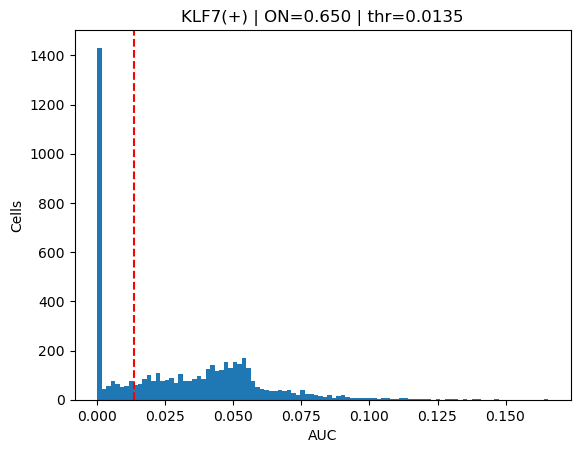

In [17]:
on_fraction.loc[[r for r in on_fraction.index if "GLI2" in r]]

reg = "KLF7(+)"

print("AUC describe:")
display(auc_df[reg].describe())

print("Threshold:")
print(auc_thresholds.loc[reg])

print("ON fraction:")
print(binary_mtx[reg].mean())

plt.hist(auc_df[reg], bins=100)
plt.axvline(auc_thresholds.loc[reg], linestyle="--", color="red")
plt.title(f"{reg} | ON={binary_mtx[reg].mean():.3f} | thr={auc_thresholds.loc[reg]:.4f}")
plt.xlabel("AUC")
plt.ylabel("Cells")
plt.show()

## 6. Inspección visual de las distribuciones de AUC y de los umbrales

En este paso inspeccionamos algunos de los regulones más frecuentemente ON y superponemos el umbral de binarización.

Esto sirve para comprobar que la binarización no sea incoherente.

- Inspección de regulones ON:

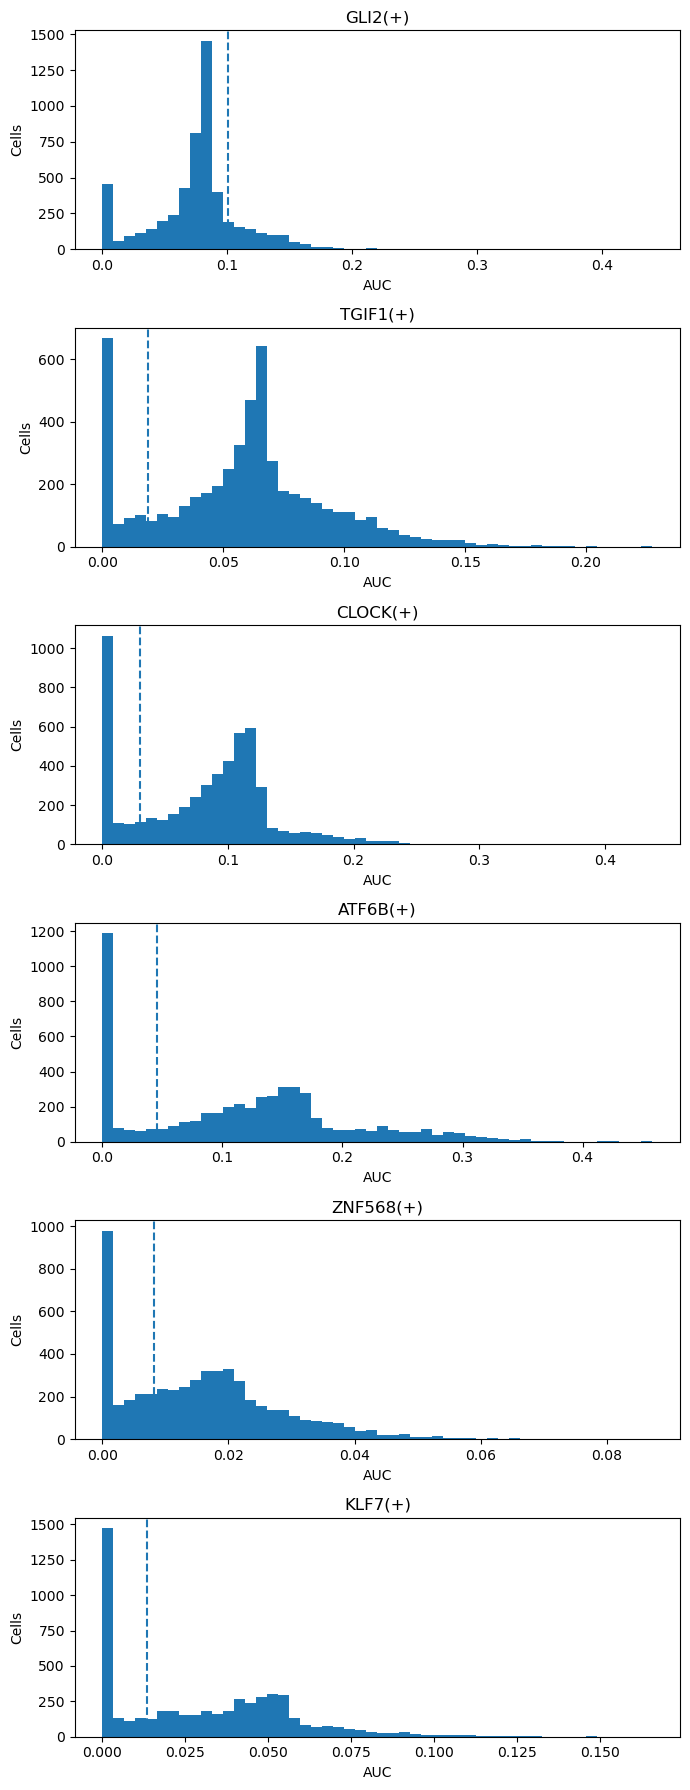

In [18]:
preferred = ["GLI2(+)", "TGIF1(+)", "CLOCK(+)", "ATF6B(+)", "ZNF568(+)", "KLF7(+)"]
plot_regs = [r for r in preferred if r in auc_df.columns]

if len(plot_regs) == 0:
    plot_regs = auc_df.columns[:6].tolist()

fig, axes = plt.subplots(len(plot_regs), 1, figsize=(7, 3 * len(plot_regs)))
if len(plot_regs) == 1:
    axes = [axes]

for ax, reg in zip(axes, plot_regs):
    ax.hist(auc_df[reg].values, bins=50)
    ax.axvline(auc_thresholds.loc[reg], linestyle="--")
    ax.set_title(reg)
    ax.set_xlabel("AUC")
    ax.set_ylabel("Cells")

plt.tight_layout()
fig.savefig(FIGURES / "01_histogramas_regulones_biologicos.png", dpi=300, bbox_inches="tight")
plt.show()

- Opcional: Dip test de bimodalidad de Hartigan (lo realiza AUCell pero no conserva las métricas, nos sirve para buscar distribuciones bimodales)

In [19]:
from pyscenic.diptest import diptst

dip_rows = []

for reg in auc_df.columns:
    x = np.sort(auc_df[reg].astype(float).values)
    dip, pval, _ = diptst(x)

    dip_rows.append({
        "regulon": reg,
        "dip": dip,
        "pval": pval if pval is not None else np.nan,
        "on_fraction": binary_mtx[reg].mean(),
        "zero_fraction": (auc_df[reg] == 0).mean(),
        "threshold": auc_thresholds.loc[reg],
        "mean_auc": auc_df[reg].mean(),
        "sd_auc": auc_df[reg].std()
    })

dip_df = pd.DataFrame(dip_rows).set_index("regulon")
dip_df.to_csv(TABLES / "01_diptest_regulones.tsv", sep="\t")

- Opcional: Inspección visual de distribuciones unimodales/continuas vs bimodales según el dip test

Candidatos continuos/unimodales:


,dip,pval,on_fraction,zero_fraction,threshold
regulon,,,,,
BRCA1(+),0.002002,1.0,0.055911,0.0,0.064472
NFKB2(+),0.002127,1.0,0.029932,0.0,0.058162
SMARCA4(+),0.002149,1.0,0.055158,0.0,0.048447
RB1(+),0.002158,1.0,0.048758,0.0,0.057134
PHF8(+),0.002229,1.0,0.028238,0.0,0.053849
BHLHE40(+),0.002270,1.0,0.045745,0.0,0.077920


Candidatos bimodales:


,dip,pval,on_fraction,zero_fraction,threshold
regulon,,,,,
STAT6(+),0.298099,0.000999,0.281815,0.596197,0.024012
FOSL1(+),0.290004,0.000999,0.304782,0.580008,0.011487
HOXC6(+),0.281532,0.000999,0.374623,0.563065,0.030413
SNAPC4(+),0.268261,0.000999,0.371235,0.536521,0.028849
MECP2(+),0.249341,0.000999,0.404179,0.498682,0.027361
RARG(+),0.230516,0.000999,0.258848,0.461032,0.048595


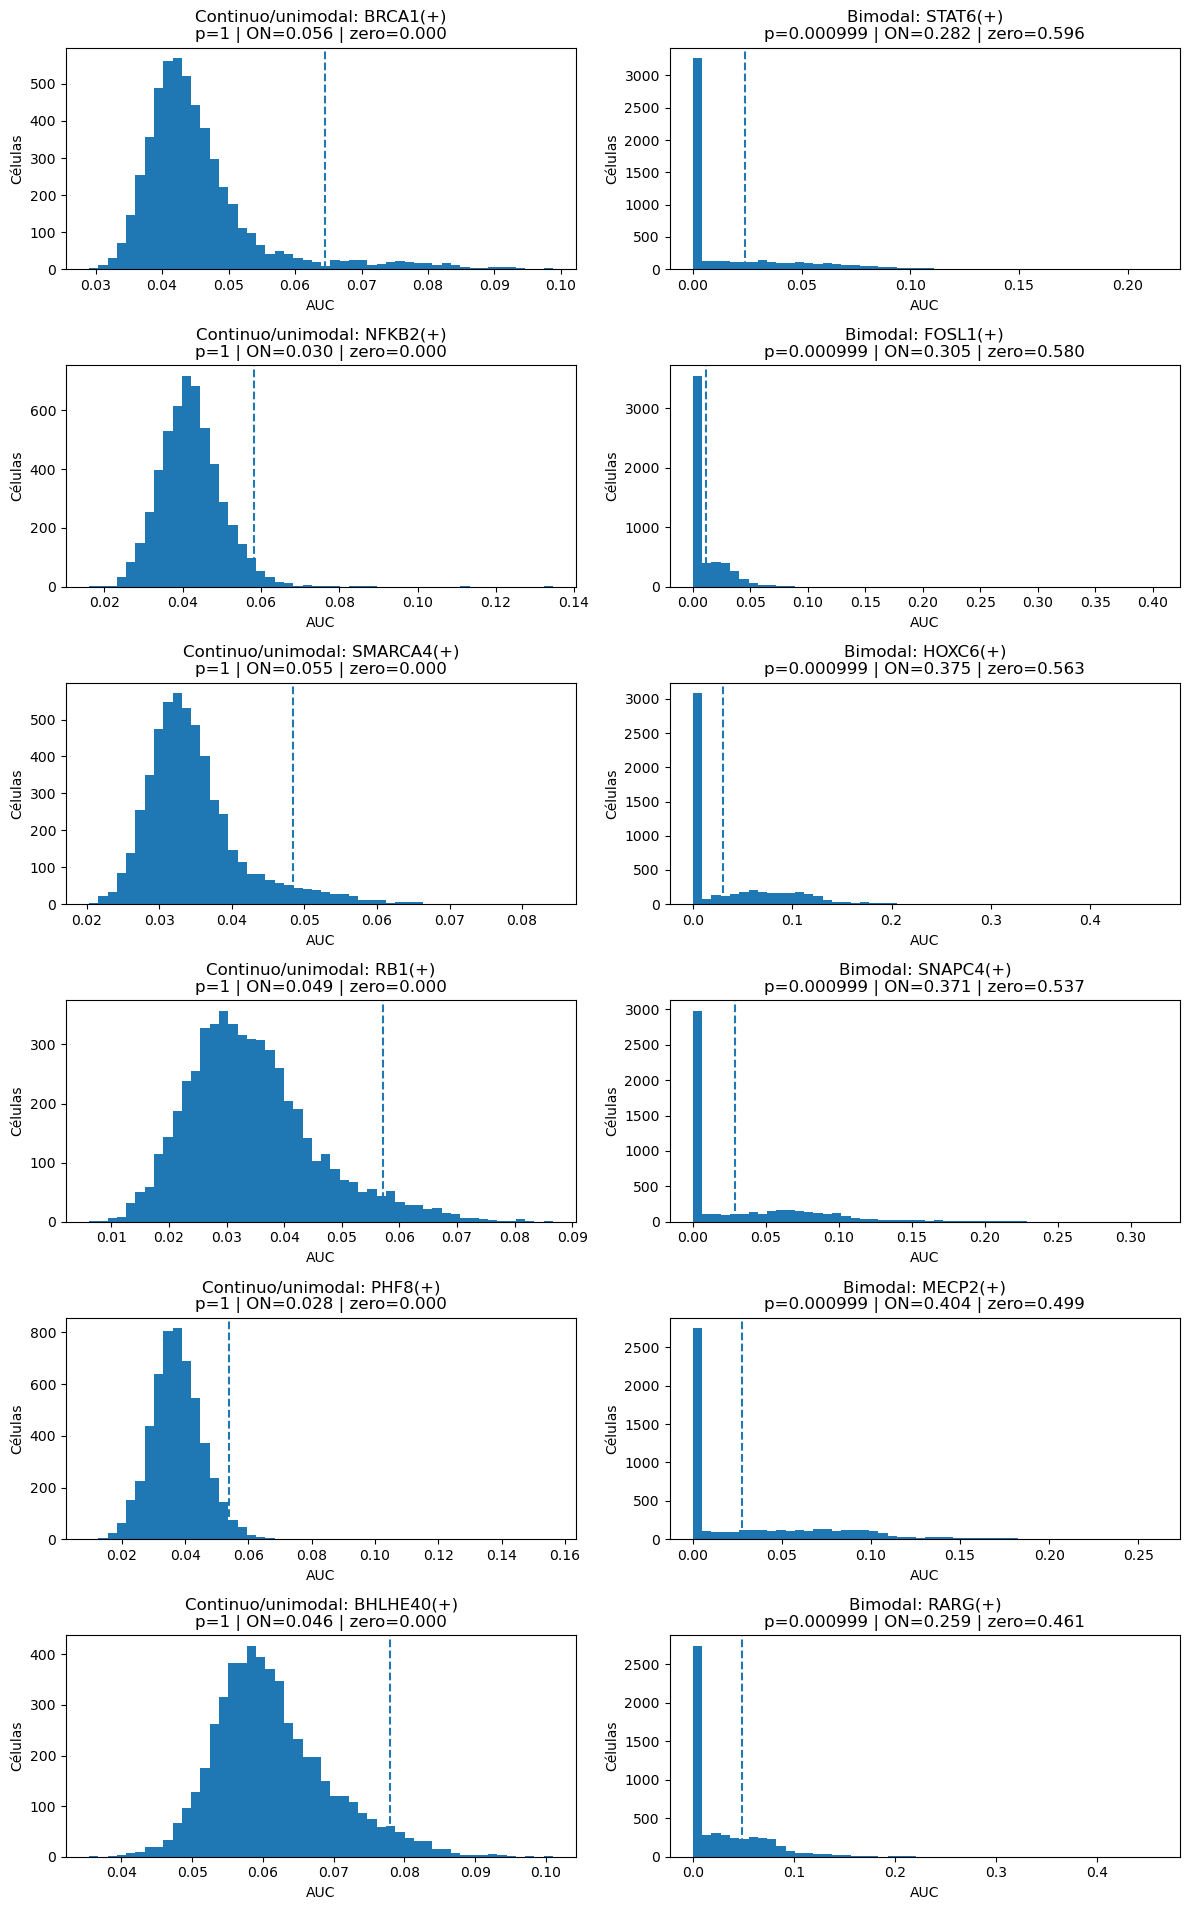

In [20]:
continuous_df = (
    dip_df.loc[
        dip_df["pval"].notna() &
        (dip_df["zero_fraction"] <= 0.05)
    ]
    .sort_values(["pval", "dip"], ascending=[False, True])
    .head(6)
)

bimodal_df = (
    dip_df.loc[
        dip_df["pval"].notna() &
        (dip_df["on_fraction"] >= 0.25) &
        (dip_df["on_fraction"] <= 0.75) &
        (dip_df["zero_fraction"] <= 0.60)
    ]
    .sort_values(["pval", "dip"], ascending=[True, False])
    .head(6)
)

print("Candidatos continuos/unimodales:")
display(continuous_df[["dip", "pval", "on_fraction", "zero_fraction", "threshold"]])
print("Candidatos bimodales:")
display(bimodal_df[["dip", "pval", "on_fraction", "zero_fraction", "threshold"]])

plot_regs_uni = continuous_df.index.tolist()
plot_regs_bi = bimodal_df.index.tolist()
n_rows = max(len(plot_regs_uni), len(plot_regs_bi))

fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.2 * n_rows))
axes = np.atleast_2d(axes)

for col, regs, label in [
    (0, plot_regs_uni, "Continuo/unimodal"),
    (1, plot_regs_bi, "Bimodal")
]:
    for i in range(n_rows):
        ax = axes[i, col]

        if i >= len(regs):
            ax.axis("off")
            continue

        reg = regs[i]
        ax.hist(auc_df[reg], bins=50)
        ax.axvline(auc_thresholds.loc[reg], linestyle="--")
        ax.set_title(
            f"{label}: {reg}\n"
            f"p={dip_df.loc[reg, 'pval']:.3g} | "
            f"ON={dip_df.loc[reg, 'on_fraction']:.3f} | "
            f"zero={dip_df.loc[reg, 'zero_fraction']:.3f}"
        )
        ax.set_xlabel("AUC")
        ax.set_ylabel("Células")

plt.tight_layout()
fig.savefig(FIGURES / "01_regulones_continuos_vs_bimodales.png", dpi=300, bbox_inches="tight")
plt.show()

- Inspección de regulones según criterios técnicos (6 con mayor varianza de AUC y 6 con ON fraction intermedia):

Regulones con mayor varianza de AUC:


,var_auc,on_fraction,threshold
ATF6B(+),0.007990,0.723833,0.045471
BATF(+),0.007789,0.047252,0.370701
TCF4(+),0.005905,0.557417,0.144948
FOXP1(+),0.004853,0.507342,0.038522
ZNF845(+),0.004075,0.307229,0.042343
XBP1(+),0.003990,0.614270,0.173259


Regulones con ON fraction más cercana a 0.35:


,var_auc,on_fraction,threshold,dist_to_target
E2F5(+),0.000571,0.341867,0.028296,0.008133
SNAPC4(+),0.002150,0.371235,0.028849,0.021235
TCF3(+),0.000184,0.326995,0.014683,0.023005
HOXC6(+),0.002529,0.374623,0.030413,0.024623
ZNF121(+),0.000853,0.376130,0.035130,0.026130
ETV2(+),0.000102,0.322477,0.011317,0.027523


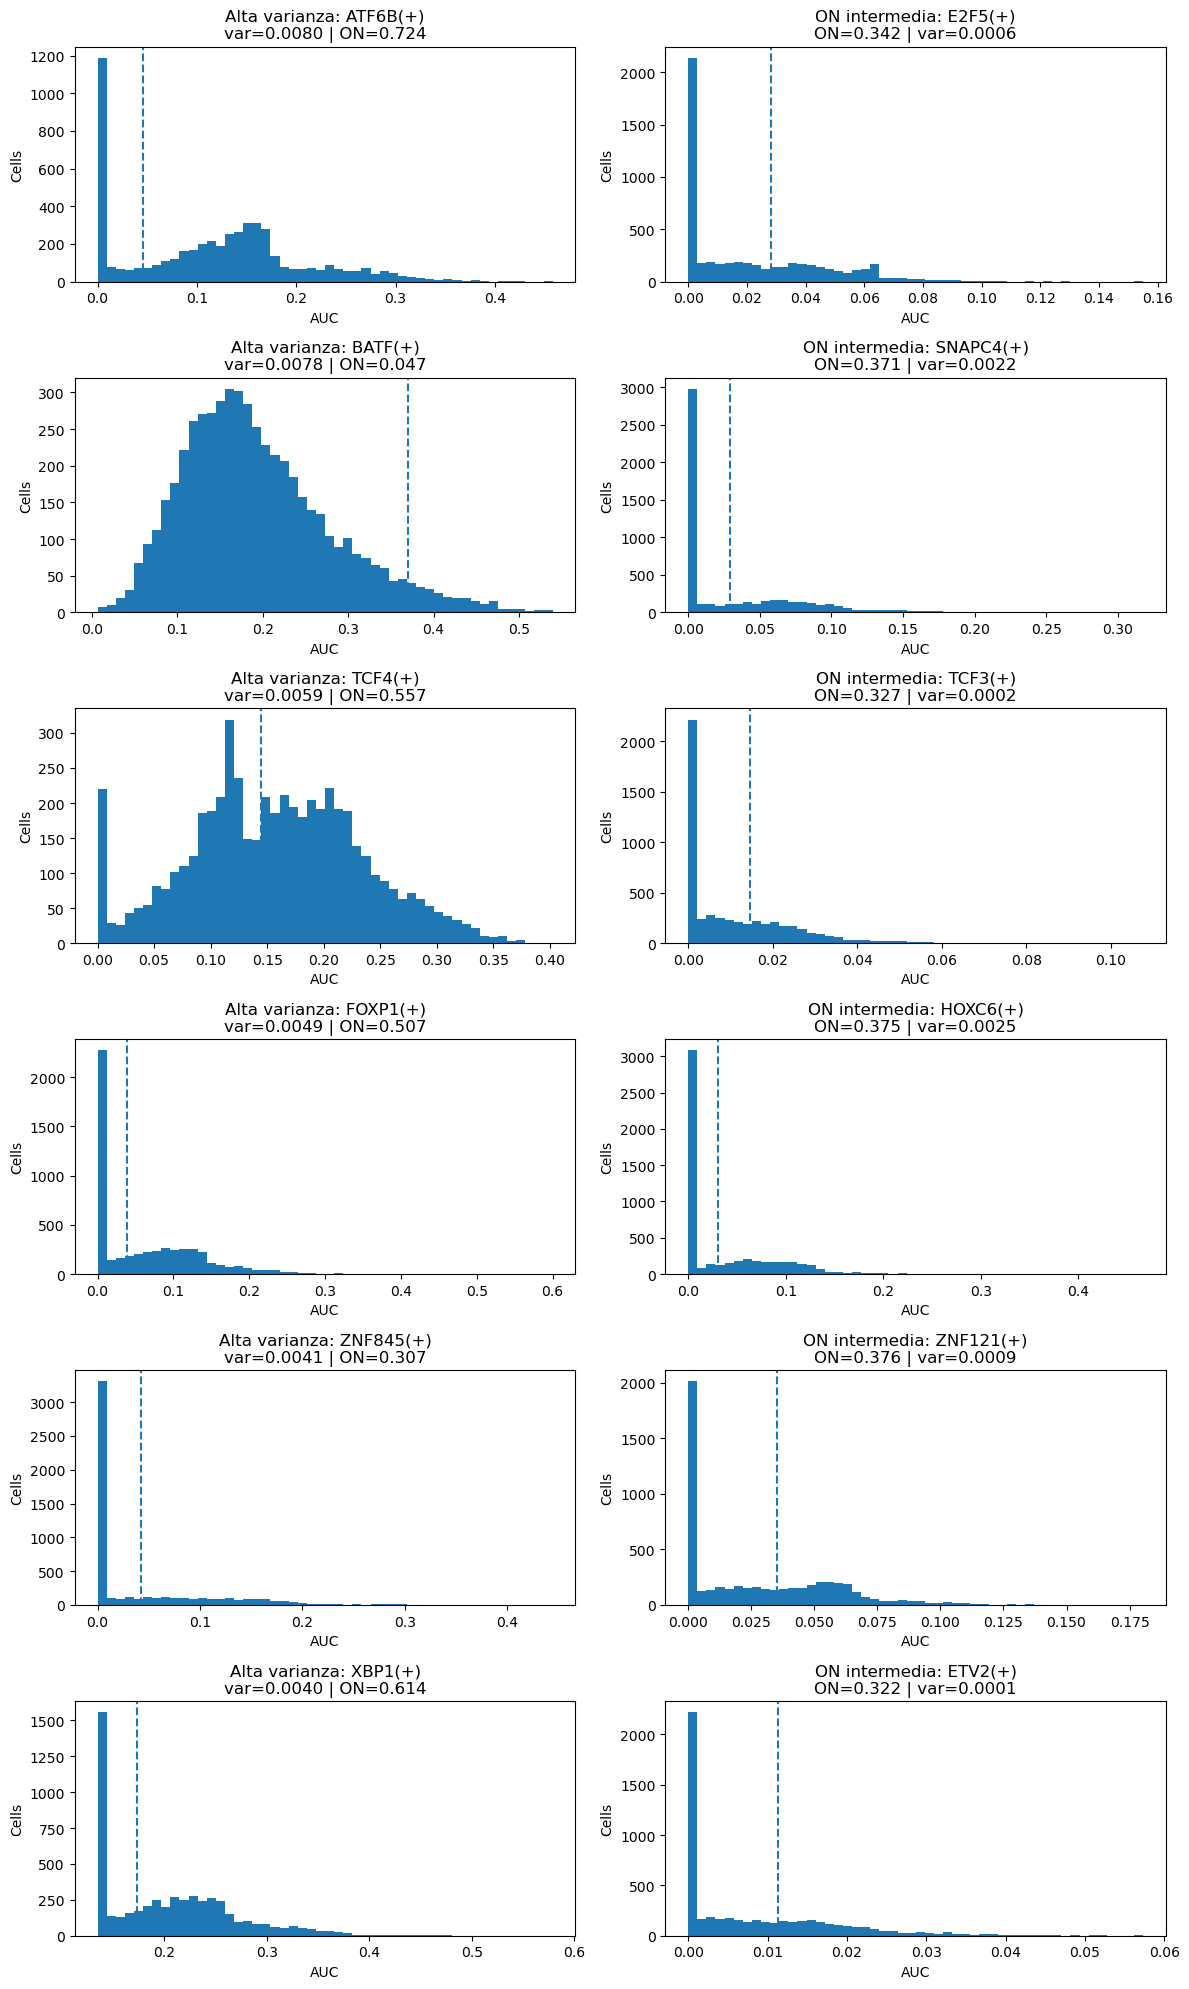

In [21]:
qc_df = pd.DataFrame({
    "var_auc": auc_df.var(axis=0),
    "on_fraction": binary_mtx.mean(axis=0),
    "threshold": auc_thresholds
})

qc_df.to_csv(TABLES / "01_qc_regulones_var_onfraction_threshold.tsv", sep="\t")

top_var_df = qc_df.sort_values("var_auc", ascending=False).head(6)

target_on = 0.35
mid_on_df = (
    qc_df.assign(dist_to_target=(qc_df["on_fraction"] - target_on).abs())
    .sort_values(["dist_to_target", "var_auc"], ascending=[True, False])
    .head(6)
)

mid_on_df[["var_auc", "on_fraction", "threshold", "dist_to_target"]].to_csv(
    TABLES / "01_regulones_on_fraction_intermedia.tsv", sep="\t"
)

print("Regulones con mayor varianza de AUC:")
display(top_var_df)

print(f"Regulones con ON fraction más cercana a {target_on}:")
display(mid_on_df[["var_auc", "on_fraction", "threshold", "dist_to_target"]])

fig, axes = plt.subplots(6, 2, figsize=(12, 20))
axes = np.atleast_2d(axes)

for i, reg in enumerate(top_var_df.index.tolist()):
    ax = axes[i, 0]
    ax.hist(auc_df[reg].values, bins=50)
    ax.axvline(auc_thresholds.loc[reg], linestyle="--")
    ax.set_title(
        f"Alta varianza: {reg}\n"
        f"var={qc_df.loc[reg, 'var_auc']:.4f} | "
        f"ON={qc_df.loc[reg, 'on_fraction']:.3f}"
    )
    ax.set_xlabel("AUC")
    ax.set_ylabel("Cells")

for i, reg in enumerate(mid_on_df.index.tolist()):
    ax = axes[i, 1]
    ax.hist(auc_df[reg].values, bins=50)
    ax.axvline(auc_thresholds.loc[reg], linestyle="--")
    ax.set_title(
        f"ON intermedia: {reg}\n"
        f"ON={qc_df.loc[reg, 'on_fraction']:.3f} | "
        f"var={qc_df.loc[reg, 'var_auc']:.4f}"
    )
    ax.set_xlabel("AUC")
    ax.set_ylabel("Cells")

plt.tight_layout()
fig.savefig(FIGURES / "01_regulones_alta_varianza_vs_on_intermedia.png", dpi=300, bbox_inches="tight")
plt.show()

- inspección adicional (paper-like)

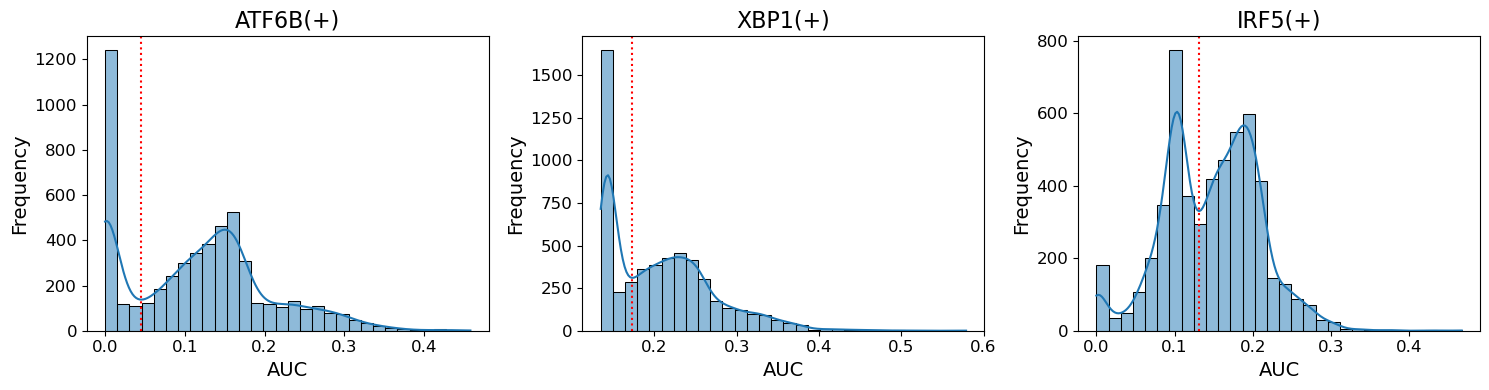

In [22]:
import seaborn as sns

# Regulones de ejemplo para una figura tipo Fig. 6
example_regs = ["ATF6B(+)", "XBP1(+)", "IRF5(+)"]
example_regs = [r for r in example_regs if r in auc_df.columns]

if len(example_regs) == 0:
    example_regs = auc_df.columns[:3].tolist()

fig, axes = plt.subplots(1, len(example_regs), figsize=(5 * len(example_regs), 4), sharey=False)

if len(example_regs) == 1: axes = [axes]

for ax, reg in zip(axes, example_regs):
    sns.histplot(auc_df[reg].values, bins=30, kde=True,
        ax=ax
    )
    ax.axvline(
        auc_thresholds.loc[reg],
        color="red",
        linestyle=":",
        linewidth=1.5
    )
    ax.set_title(reg, fontsize=16)
    ax.set_xlabel("AUC", fontsize=14)
    ax.set_ylabel("Frequency", fontsize=14)
    ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
fig.savefig(FIGURES / "01_auc_distributions_example_regulons_paper_style.png", dpi=300, bbox_inches="tight")
plt.show()

- paper-like (bimodales limpios)

,dip,pval,on_fraction,zero_fraction,threshold
regulon,,,,,
KLF16(+),0.124718,0.000999,0.579631,0.249435,0.006703
ZNF358(+),0.123494,0.000999,0.632907,0.246988,0.005567
ATF6B(+),0.104104,0.000999,0.723833,0.208208,0.045471


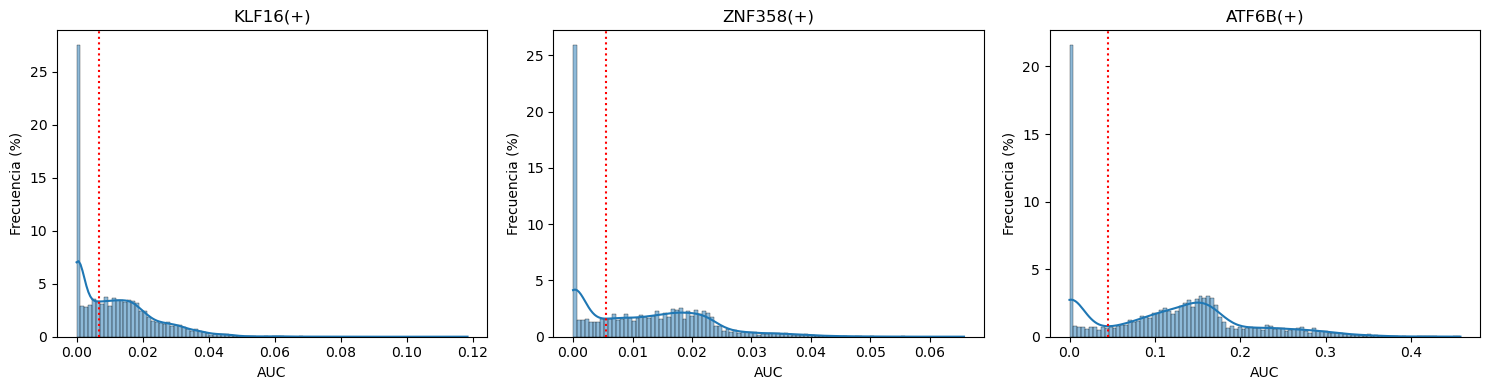

In [23]:
import seaborn as sns

# Selección de regulones con distribución no unimodal y sin pico masivo en cero
bimodal_fig_df = (
    dip_df.loc[
        dip_df["pval"].notna() &
        (dip_df["pval"] <= 0.05) &
        (dip_df["on_fraction"] >= 0.20) &
        (dip_df["on_fraction"] <= 0.80) &
        (dip_df["zero_fraction"] <= 0.25)
    ]
    .sort_values(["dip", "pval"], ascending=[False, True])
    .head(3)
)

# Fallback si el filtro estricto devuelve menos de 3 regulones
if bimodal_fig_df.shape[0] < 3:
    bimodal_fig_df = (
        dip_df.loc[
            dip_df["pval"].notna() &
            (dip_df["pval"] <= 0.05) &
            (dip_df["on_fraction"] >= 0.15) &
            (dip_df["on_fraction"] <= 0.85) &
            (dip_df["zero_fraction"] <= 0.40)
        ]
        .sort_values(["dip", "pval"], ascending=[False, True])
        .head(3)
    )

plot_regs = bimodal_fig_df.index.tolist()

display(bimodal_fig_df[["dip", "pval", "on_fraction", "zero_fraction", "threshold"]])

fig, axes = plt.subplots(1, len(plot_regs), figsize=(5 * len(plot_regs), 4), sharey=False)
axes = np.atleast_1d(axes)

for ax, reg in zip(axes, plot_regs):
    sns.histplot(
        auc_df[reg],
        bins=100,
        stat="percent",
        kde=True,
        ax=ax
    )
    ax.axvline(
        auc_thresholds.loc[reg],
        color="red",
        linestyle=":",
        linewidth=1.5
    )
    ax.set_title(reg)
    ax.set_xlabel("AUC")
    ax.set_ylabel("Frecuencia (%)")

plt.tight_layout()
fig.savefig(FIGURES / "01_auc_distributions_bimodal_examples.png", dpi=300, bbox_inches="tight")
plt.show()

- paper-like con estimación de la densidad de Kernel

Regulones con picos positivos mejor definidos:


,positive_bimodality_score,n_peaks_positive,on_fraction,zero_fraction,threshold
regulon,,,,,
XBP1(+),4.605215,2,0.614270,0.000000,0.173259
IRF5(+),3.417883,2,0.588479,0.025414,0.131452


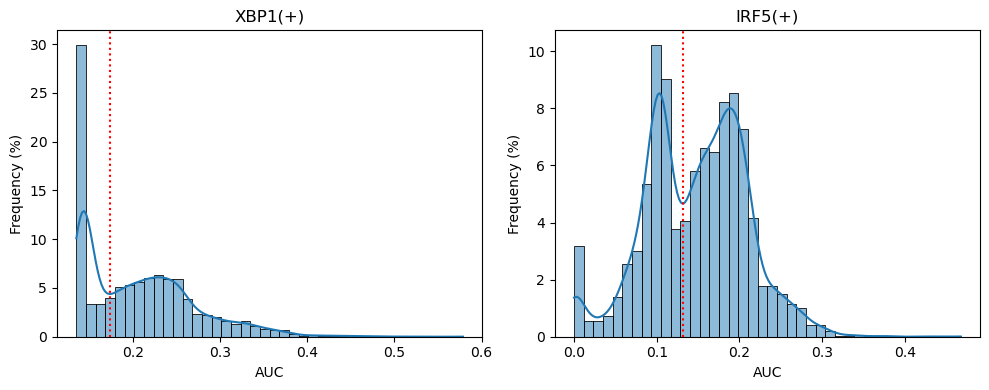

In [24]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks

def positive_bimodality_score(x, min_auc=0.005, grid_n=512):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x[x > min_auc]

    if len(x) < 50:
        return {
            "n_positive": len(x),
            "n_peaks": 0,
            "peak_positions": [],
            "peak_heights": [],
            "score": np.nan
        }

    grid = np.linspace(x.min(), x.max(), grid_n)
    kde = gaussian_kde(x)
    y = kde(grid)

    peaks, _ = find_peaks(y, prominence=np.max(y) * 0.08, distance=grid_n // 8)

    peak_positions = grid[peaks]
    peak_heights = y[peaks]

    if len(peaks) >= 2:
        order = np.argsort(peak_heights)[::-1]
        top2 = np.sort(peaks[order[:2]])
        p1, p2 = top2[0], top2[1]
        valley = np.min(y[p1:p2 + 1])
        mean_peak = np.mean([y[p1], y[p2]])
        score = mean_peak - valley
    else:
        score = np.nan

    return {
        "n_positive": len(x),
        "n_peaks": len(peaks),
        "peak_positions": peak_positions.tolist(),
        "peak_heights": peak_heights.tolist(),
        "score": score
    }

peak_rows = []
for reg in auc_df.columns:
    thr = float(auc_thresholds.loc[reg])
    vals = auc_df[reg].values

    stats = positive_bimodality_score(vals, min_auc=0.005)

    peak_rows.append({
        "regulon": reg,
        "n_positive": stats["n_positive"],
        "n_peaks_positive": stats["n_peaks"],
        "positive_bimodality_score": stats["score"],
        "peak_positions_positive": str(stats["peak_positions"]),
        "on_fraction": float((auc_df[reg] > thr).mean()),
        "zero_fraction": float((auc_df[reg] == 0).mean()),
        "threshold": thr
    })

peak_df = pd.DataFrame(peak_rows).set_index("regulon")

bimodal_fig_df = (
    peak_df.loc[
        (peak_df["zero_fraction"] <= 0.10) &
        (peak_df["on_fraction"] >= 0.15) &
        (peak_df["on_fraction"] <= 0.85) &
        (peak_df["n_peaks_positive"] >= 2) &
        peak_df["positive_bimodality_score"].notna()
    ]
    .sort_values(
        ["positive_bimodality_score", "zero_fraction"],
        ascending=[False, True]
    )
    .head(3)
)

if bimodal_fig_df.shape[0] < 3:
    bimodal_fig_df = (
        peak_df.loc[
            (peak_df["zero_fraction"] <= 0.20) &
            (peak_df["on_fraction"] >= 0.10) &
            (peak_df["on_fraction"] <= 0.90) &
            (peak_df["n_peaks_positive"] >= 2) &
            peak_df["positive_bimodality_score"].notna()
        ]
        .sort_values(
            ["positive_bimodality_score", "zero_fraction"],
            ascending=[False, True]
        )
        .head(3)
    )

plot_regs = bimodal_fig_df.index.tolist()
print("Regulones con picos positivos mejor definidos:")
display(bimodal_fig_df[["positive_bimodality_score", "n_peaks_positive", "on_fraction", "zero_fraction", "threshold"]])
fig, axes = plt.subplots(1, len(plot_regs), figsize=(5 * len(plot_regs), 4), sharey=False)

if len(plot_regs) == 1:
    axes = [axes]

for ax, reg in zip(axes, plot_regs):
    sns.histplot(
        auc_df[reg].values,
        bins=40,
        stat="percent",
        kde=True,
        ax=ax
    )
    ax.axvline(
        auc_thresholds.loc[reg],
        color="red",
        linestyle=":",
        linewidth=1.5
    )
    ax.set_title(reg)
    ax.set_xlabel("AUC")
    ax.set_ylabel("Frequency (%)")

plt.tight_layout()
fig.savefig(FIGURES / "01_auc_distributions_bimodal_examples.png", dpi=300, bbox_inches="tight")
plt.show()

- muestreo aleatorio de regulones

Regulones seleccionados: ['POLR3G(+)', 'KLF3(+)', 'SREBF2(+)']


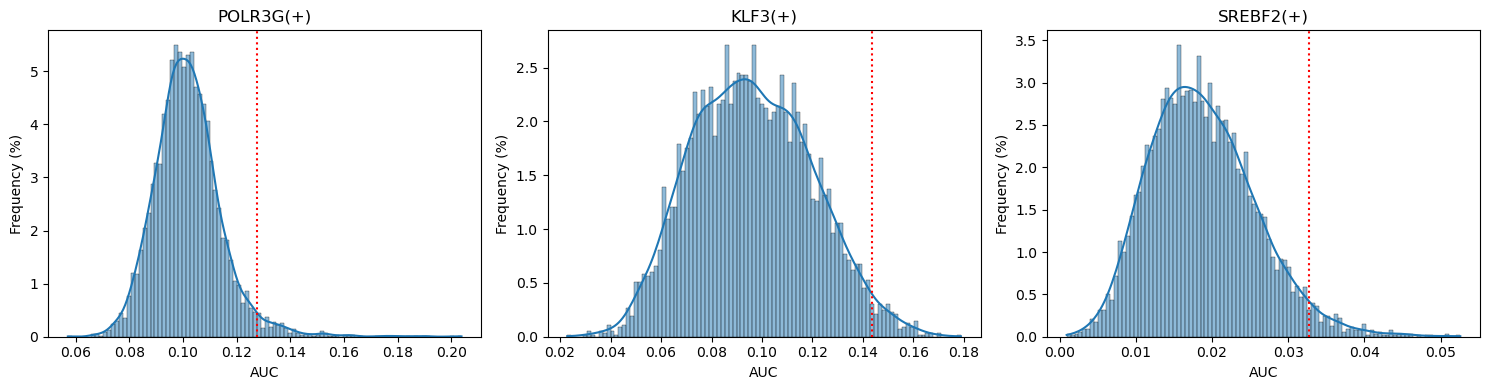

In [25]:
import numpy as np
import seaborn as sns

candidate_regs = auc_df.columns.tolist()

# Muestreo aleatorio de 3 regulones
plot_regs = np.random.choice(candidate_regs, size=3, replace=False).tolist()
print("Regulones seleccionados:", plot_regs)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)

for ax, reg in zip(axes, plot_regs):
    sns.histplot(
        auc_df[reg].values,
        bins=100,
        stat="percent",
        kde=True,
        ax=ax
    )
    ax.axvline(
        auc_thresholds.loc[reg],
        color="red",
        linestyle=":",
        linewidth=1.5
    )
    ax.set_title(reg)
    ax.set_xlabel("AUC")
    ax.set_ylabel("Frequency (%)")

plt.tight_layout()
plt.show()

## 7. Crear un objeto `AnnData` en el espacio de regulones

Ahora almacenamos la matriz de actividad de regulones en un objeto `AnnData`.

Este objeto contendrá:
- los valores continuos de AUC como matriz principal
- los metadatos celulares en `obs`
- la actividad binaria de regulones como capa adicional

In [26]:
adata_auc = sc.AnnData(X=auc_df.values, obs=meta_df.copy(), var=pd.DataFrame(index=auc_df.columns))
adata_auc.obs_names = auc_df.index
adata_auc.var_names = auc_df.columns
adata_auc.layers["binary"] = binary_mtx.values.astype(np.int8)
adata_auc.var["threshold"] = auc_thresholds.loc[adata_auc.var_names]

print(adata_auc)

AnnData object with n_obs × n_vars = 5312 × 276
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'nCount_HTO', 'nFeature_HTO', 'HTO_maxID', 'HTO_secondID', 'HTO_margin', 'HTO_classification', 'HTO_classification.global', 'hash.ID', 'Sample', 'Treatment', 'Replicate', 'percent.mt', 'percent.ribo', 'miQC.probability', 'miQC.keep'
    var: 'threshold'
    layers: 'binary'


## 8. Calcular el grafo de vecinos, UMAP, t-SNE y clustering en espacio de regulones

Este es el paso específico en SCENIC para proyección no lineal y clustering.

Es independiente de la proyección y clustering realizado en Seurat, más adelante se integrarán.

In [27]:
sc.pp.neighbors(adata_auc, n_neighbors=15, metric="correlation", use_rep="X")
sc.tl.umap(adata_auc, random_state=0)
sc.tl.tsne(adata_auc, random_state=0, use_rep="X")

sc.tl.leiden(adata_auc, key_added="SCENIC_cluster_L1", resolution=0.5, random_state=0)
sc.tl.leiden(adata_auc, key_added="SCENIC_cluster_L2", resolution=0.9, random_state=0)

adata_auc.obs["SCENIC_cluster_L1"] = adata_auc.obs["SCENIC_cluster_L1"].astype(str)
adata_auc.obs["SCENIC_cluster_L2"] = adata_auc.obs["SCENIC_cluster_L2"].astype(str)

cluster_counts_L1 = adata_auc.obs["SCENIC_cluster_L1"].value_counts().sort_index()
cluster_counts_L2 = adata_auc.obs["SCENIC_cluster_L2"].value_counts().sort_index()

cluster_counts_L1.to_csv(TABLES / "01_scenic_cluster_counts_L1.tsv", sep="\t", header=True)
cluster_counts_L2.to_csv(TABLES / "01_scenic_cluster_counts_L2.tsv", sep="\t", header=True)

print(cluster_counts_L1)
print(cluster_counts_L2)

/tmp/ipykernel_2556719/2284005177.py:5: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_auc, key_added="SCENIC_cluster_L1", resolution=0.5, random_state=0)


SCENIC_cluster_L1
0    1797
1    1640
2    1554
3     321
Name: count, dtype: int64
SCENIC_cluster_L2
0    1221
1    1004
2     776
3     762
4     597
5     532
6     329
7      91
Name: count, dtype: int64


## 9. Visualizar UMAP y t-SNE basado en regulones

Estas gráficas muestran cómo se organizan las células en el espacio regulatorio.

En este punto coloreamos por:
- cluster SCENIC
- tratamiento
- réplica

UMAP

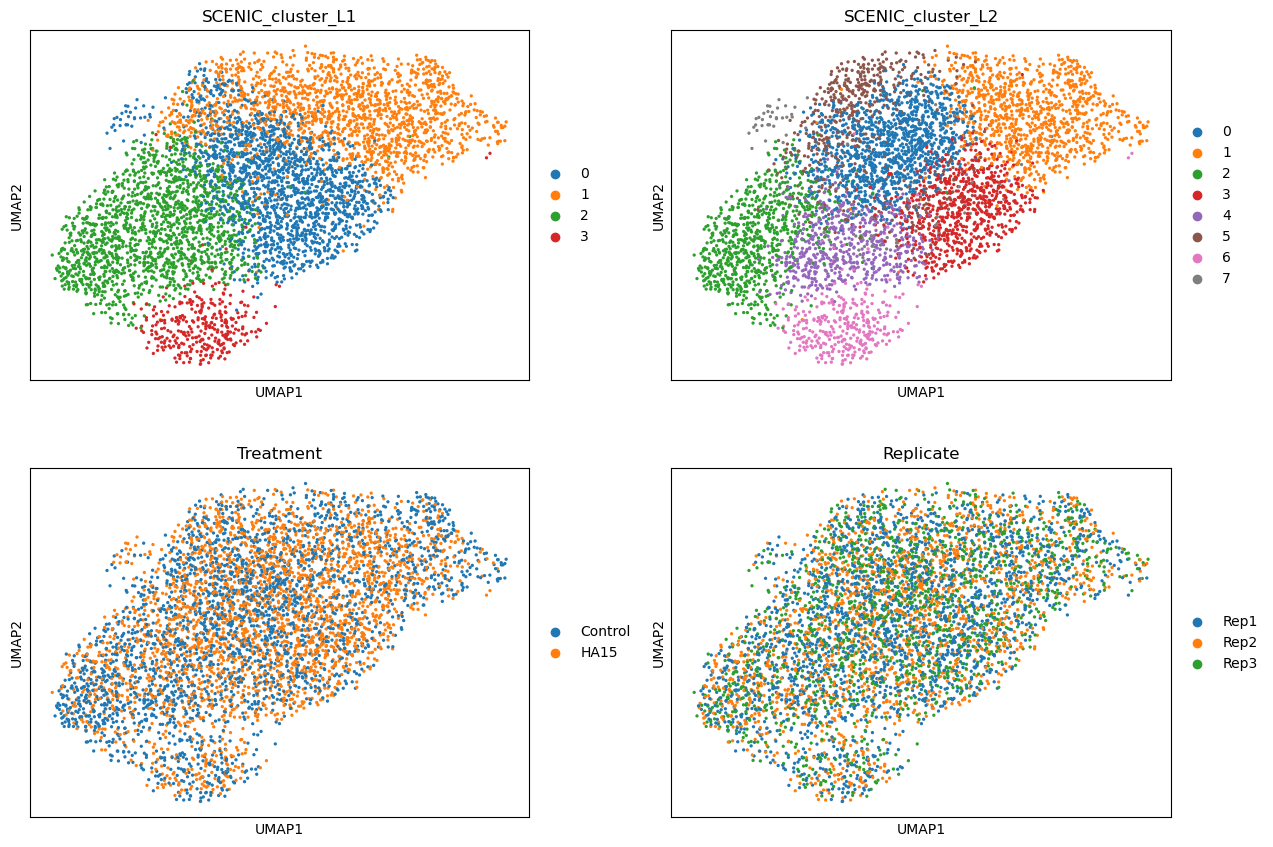

In [28]:
sc.pl.umap(adata_auc,
    color=["SCENIC_cluster_L1", "SCENIC_cluster_L2", "Treatment", "Replicate"],
    ncols=2, wspace=0.17, show=False)

plt.savefig(
    FIGURES / "01_umap_scenic_clusters_L1_L2_treatment_replicate.png",
    dpi=300, bbox_inches="tight")
plt.show()

t-SNE

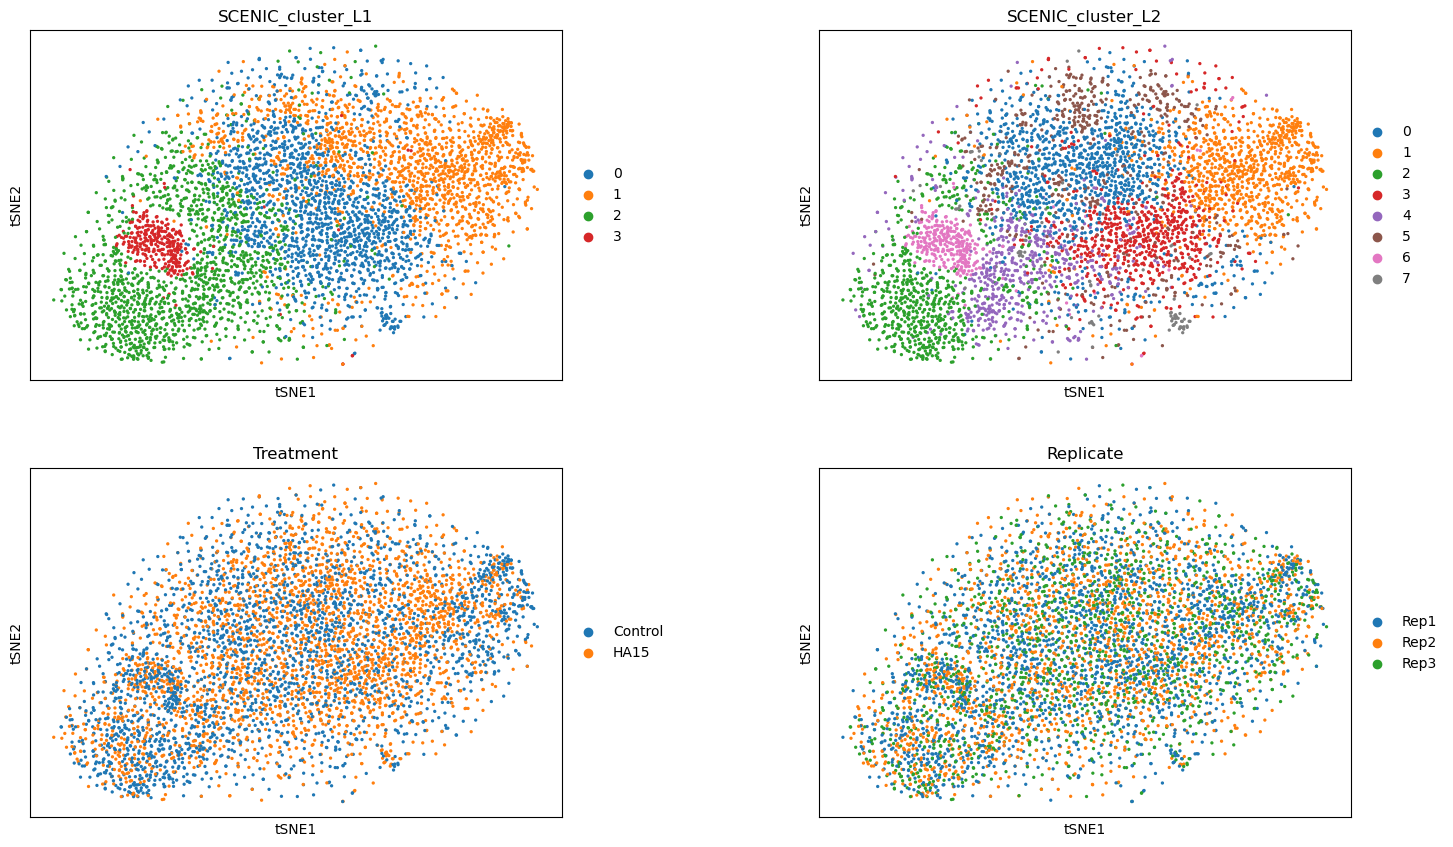

In [29]:
sc.pl.tsne(adata_auc,
    color=["SCENIC_cluster_L1", "SCENIC_cluster_L2", "Treatment", "Replicate"],
    ncols=2, wspace=0.35,show=False)

plt.savefig(FIGURES / "01_tsne_scenic_clusters_L1_L2_treatment_replicate.png", dpi=300, bbox_inches="tight")
plt.show()

- nota: repetir visualizaciones estratificando por VIHpos / VIHneg en la notebook 2

## 10. Preparar archivo `reg.csv` para las siguientes notebooks

Ahora parseamos el archivo de metadata de regulones generado por pySCENIC para dejarlo limpio y disponible para los siguientes notebooks. Este paso facilita el uso posterior de los metadatos de regulones para explorar TFs, soporte por motivos y genes diana.
- Revisión de metadatos:

In [30]:
reg_df = pd.read_csv(reg_path, header=[0, 1])
print(reg_df.shape)
reg_df.head(3)

(12873, 10)


Unnamed: 0_level_0                  Unnamed: 1_level_0 Enrichment            \
  Unnamed: 0_level_1                  Unnamed: 1_level_1        AUC       NES   
0                 TF                             MotifID        NaN       NaN   
1                AHR  dbcorrdb__BRCA1__ENCSR000EBX_1__m1   0.053785  3.011207   
2               ATF1                        cisbp__M4307   0.053534  3.126436   

                                             \
  MotifSimilarityQvalue OrthologousIdentity   
0                   NaN                 NaN   
1              0.000834                 1.0   
2              0.000184                 1.0   

                                                      \
                                          Annotation   
0                                                NaN   
1  motif similar to cisbp__M2917 ('AHRR[gene ID: ...   
2  gene is annotated for similar motif dbcorrdb__...   

                                                      \
                                             Context   
0                                                NaN   
1  frozenset({'hg38__refseq-r80__10kb_up_and_down...   
2  frozenset({'hg38__refseq-r80__10kb_up_and_down...   

                                                                
                                         TargetGenes RankAtMax  
0                                                NaN       NaN  
1  [('IREB2', 0.5907187630038518), ('SLC12A2', 3....     607.0  
2  [('PAK1', 0.9351716282818048), ('ELL2', 0.5044...    1341.0

- Aplanar y estandarizar los nombres de columna de `reg.csv`

In [31]:
# Copia de trabajo
reg_df = reg_df.copy()

# Renombrar manualmente las 2 primeras columnas, que vienen sin nombre útil
new_cols = list(reg_df.columns)
new_cols[0] = ("TF", "TF")
new_cols[1] = ("MotifID", "MotifID")
reg_df.columns = pd.MultiIndex.from_tuples(new_cols)

# Eliminar la primera fila espuria, que contiene "TF", "MotifID", etc.
if str(reg_df.iloc[0, 0]) == "TF" and str(reg_df.iloc[0, 1]) == "MotifID":
    reg_df = reg_df.iloc[1:].copy()

# Aplanar nombres de columna
reg_df.columns = [f"{c0}_{c1}".strip("_")
    for c0, c1 in reg_df.columns]

# Renombrar a nombres limpios
rename_map = {"TF_TF": "TF",
    "MotifID_MotifID": "MotifID",
    "Enrichment_AUC": "AUC",
    "Enrichment_NES": "NES",
    "Enrichment_MotifSimilarityQvalue": "MotifSimilarityQvalue",
    "Enrichment_OrthologousIdentity": "OrthologousIdentity",
    "Enrichment_Annotation": "Annotation",
    "Enrichment_Context": "Context",
    "Enrichment_TargetGenes": "TargetGenes",
    "Enrichment_RankAtMax": "RankAtMax",
}
reg_df = reg_df.rename(columns=rename_map)
reg_df = reg_df.reset_index(drop=True)

reg_df.to_csv(PROC / "01_regulons_metadata.tsv", sep="\t", index=False)

print("shape limpio:", reg_df.shape)
print(reg_df.columns.tolist())
display(reg_df.head(3))

shape limpio: (12872, 10)
['TF', 'MotifID', 'AUC', 'NES', 'MotifSimilarityQvalue', 'OrthologousIdentity', 'Annotation', 'Context', 'TargetGenes', 'RankAtMax']


,TF,MotifID,AUC,NES,MotifSimilarityQvalue,OrthologousIdentity,Annotation,Context,TargetGenes,RankAtMax
0,AHR,dbcorrdb__BRCA1__ENCSR000EBX_1__m1,0.053785,3.011207,0.000834,1.0,motif similar to cisbp__M2917 ('AHRR[gene ID: ...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('IREB2', 0.5907187630038518), ('SLC12A2', 3....",607.0
1,ATF1,cisbp__M4307,0.053534,3.126436,0.000184,1.0,gene is annotated for similar motif dbcorrdb__...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('PAK1', 0.9351716282818048), ('ELL2', 0.5044...",1341.0
2,ATF1,jaspar__MA0609.1,0.054947,3.290071,0.000951,1.0,gene is annotated for similar motif homer__GAT...,frozenset({'hg38__refseq-r80__10kb_up_and_down...,"[('PAK1', 0.9351716282818048), ('MXI1', 0.9095...",1786.0


## 11. Guardar el objeto `AnnData`

El archivo `AnnData` almacena la representación en espacio de regulones junto con los metadatos, embeddings y clustering, y será útil en las siguientes libretas.

En este punto el flujo de SCENIC queda completado y lista para integrarse con el flujo de Seurat en el siguiente notebook.

In [32]:
adata_auc.write(PROC / "01_SCENIC_auc_adata.h5ad")
print("Notebook 1 completado")

Notebook 1 completado


## Adicional: inspeccionar `adj.tsv` y `reg.csv`



In [33]:
adj_df = pd.read_csv(PROC / "adj.tsv", sep="\t")

print(adj_df.shape)
print(adj_df.columns.tolist())
print("Nº adyacencias:", adj_df.shape[0])
print("Nº TFs únicos:", adj_df.iloc[:, 0].nunique())
print("Nº genes diana únicos:", adj_df.iloc[:, 1].nunique())

adj_df.head()

(4959291, 3)
['TF', 'target', 'importance']
Nº adyacencias: 4959291
Nº TFs únicos: 1331
Nº genes diana únicos: 20441


,TF,target,importance
0,RPS4X,RPS14,289.921980
1,RPS4X,RPL34,258.664928
2,BAX,RPS27L,249.428874
3,RPS4X,RPL13,248.674148
4,RPS4X,RPS3,247.405186


In [34]:
print("mean_importance:", adj_df.iloc[:, 2].mean())
print("median_importance:", adj_df.iloc[:, 2].median())
print("sd_importance:", adj_df.iloc[:, 2].std())
print("cv_importance:", adj_df.iloc[:, 2].std() / adj_df.iloc[:, 2].mean())
print("min_importance:", adj_df.iloc[:, 2].min())
print("max_importance:", adj_df.iloc[:, 2].max())

mean_importance: 0.5156626219352729
median_importance: 0.1369805113836016
sd_importance: 2.0368960413866826
cv_importance: 3.950055626956724
min_importance: 7.506284400069562e-23
max_importance: 289.9219800560317


In [35]:
import ast

print(reg_df.columns.tolist())
print("Nº módulos FT-genes diana con evidencia cis-reguladora:", reg_df.shape[0])
print("Nº TFs/regulones únicos:", reg_df["TF"].nunique())

target_genes = {
    item[0] if isinstance(item, (tuple, list)) else item
    for x in reg_df["TargetGenes"].dropna()
    for item in ast.literal_eval(x)
}
print("Nº genes diana únicos:", len(target_genes))

['TF', 'MotifID', 'AUC', 'NES', 'MotifSimilarityQvalue', 'OrthologousIdentity', 'Annotation', 'Context', 'TargetGenes', 'RankAtMax']
Nº módulos FT-genes diana con evidencia cis-reguladora: 12872
Nº TFs/regulones únicos: 276
Nº genes diana únicos: 9974


In [36]:
#distribución de genes diana por módulo
reg_df["n_targets"] = reg_df["TargetGenes"].apply(lambda x: len(ast.literal_eval(x)))

print("Nº módulos:", reg_df.shape[0])
print("Mean targets per module:", round(reg_df["n_targets"].mean(), 2))
print("Median targets per module:", round(reg_df["n_targets"].median(), 2))
print("Min targets per module:", reg_df["n_targets"].min())
print("Max targets per module:", reg_df["n_targets"].max())
print("SD targets per module:", round(reg_df["n_targets"].std(), 2))

Nº módulos: 12872
Mean targets per module: 119.31
Median targets per module: 49.0
Min targets per module: 2
Max targets per module: 1474
SD targets per module: 168.81


In [37]:
regulon_targets = {}

for _, row in reg_df.dropna(subset=["TargetGenes"]).iterrows():
    tf = row["TF"]
    targets = ast.literal_eval(row["TargetGenes"])

    if tf not in regulon_targets:
        regulon_targets[tf] = set()

    for item in targets:
        gene = item[0] if isinstance(item, (tuple, list)) else item
        regulon_targets[tf].add(gene)

n_targets_per_regulon = pd.Series({
    tf: len(genes)
    for tf, genes in regulon_targets.items()
})

print("Nº regulones únicos:", n_targets_per_regulon.shape[0])
print("Mean targets per regulon:", round(n_targets_per_regulon.mean(), 2))
print("Median targets per regulon:", round(n_targets_per_regulon.median(), 2))
print("Min targets per regulon:", n_targets_per_regulon.min())
print("Max targets per regulon:", n_targets_per_regulon.max())
print("SD targets per regulon:", round(n_targets_per_regulon.std(), 2))

Nº regulones únicos: 276
Mean targets per regulon: 236.48
Median targets per regulon: 57.5
Min targets per regulon: 2
Max targets per regulon: 3623
SD targets per regulon: 432.98


In [38]:
n_unique_targets_per_regulon = pd.Series({
    tf: len(unique_genes)
    for tf, unique_genes in regulon_targets.items()
})
n_unique_targets_per_regulon.sort_values(ascending=False).head(10)

RAD21      3623
ETS1       2516
EZH2       2445
YY1        1997
BCLAF1     1679
KDM5A      1665
IRF1       1486
BHLHE40    1318
MAZ        1298
CTCF       1286
dtype: int64

In [39]:
# Asegurar formato numérico
#reg_df["AUC"] = pd.to_numeric(reg_df["AUC"], errors="coerce")
#reg_df["NES"] = pd.to_numeric(reg_df["NES"], errors="coerce")

# -----------------------------
# AUC/NES de motivos por módulo
# -----------------------------
print("AUC por módulo")
print("Mean:", round(reg_df["AUC"].mean(), 3))
print("Median:", round(reg_df["AUC"].median(), 3))
print("Min:", round(reg_df["AUC"].min(), 3))
print("Max:", round(reg_df["AUC"].max(), 3))
print("SD:", round(reg_df["AUC"].std(), 3))

print("\nNES por módulo")
print("Mean:", round(reg_df["NES"].mean(), 3))
print("Median:", round(reg_df["NES"].median(), 3))
print("Min:", round(reg_df["NES"].min(), 3))
print("Max:", round(reg_df["NES"].max(), 3))
print("SD:", round(reg_df["NES"].std(), 3))


# -----------------------------
# AUC/NES de motivos por regulón/FT único
# usando el máximo valor observado por TF
# -----------------------------
regulon_auc_nes = (
    reg_df
    .groupby("TF")[["AUC", "NES"]]
    .max()
)

print("\nAUC por regulón")
print("Mean:", round(regulon_auc_nes["AUC"].mean(), 3))
print("Median:", round(regulon_auc_nes["AUC"].median(), 3))
print("Min:", round(regulon_auc_nes["AUC"].min(), 3))
print("Max:", round(regulon_auc_nes["AUC"].max(), 3))
print("SD:", round(regulon_auc_nes["AUC"].std(), 3))

print("\nNES por regulón")
print("Mean:", round(regulon_auc_nes["NES"].mean(), 3))
print("Median:", round(regulon_auc_nes["NES"].median(), 3))
print("Min:", round(regulon_auc_nes["NES"].min(), 3))
print("Max:", round(regulon_auc_nes["NES"].max(), 3))
print("SD:", round(regulon_auc_nes["NES"].std(), 3))

AUC por módulo
Mean: 0.076
Median: 0.064
Min: 0.038
Max: 0.473
SD: 0.037

NES por módulo
Mean: 4.042
Median: 3.662
Min: 3.0
Max: 18.611
SD: 1.409

AUC por regulón
Mean: 0.107
Median: 0.098
Min: 0.044
Max: 0.473
SD: 0.049

NES por regulón
Mean: 4.427
Median: 4.001
Min: 3.012
Max: 18.611
SD: 1.835


- QC de similitud de motivo (q-valor) e identidad ortóloga

In [40]:
reg_df["MotifSimilarityQvalue"] = pd.to_numeric(reg_df["MotifSimilarityQvalue"], errors="coerce")
reg_df["OrthologousIdentity"] = pd.to_numeric(reg_df["OrthologousIdentity"], errors="coerce")

print("Min q-value:", round(reg_df["MotifSimilarityQvalue"].min(), 6))
print("Max q-value:", round(reg_df["MotifSimilarityQvalue"].max(), 6))

print("Mean Orthologous Identity:", round(reg_df["OrthologousIdentity"].mean(), 3))
print("Median Orthologous Identity:", round(reg_df["OrthologousIdentity"].median(), 3))
print("Min Orthologous Identity:", round(reg_df["OrthologousIdentity"].min(), 3))
print("Max Orthologous Identity:", round(reg_df["OrthologousIdentity"].max(), 3))
print("SD Orthologous Identity:", round(reg_df["OrthologousIdentity"].std(), 3))

Min q-value: 0.0
Max q-value: 0.000999
Mean Orthologous Identity: 0.926
Median Orthologous Identity: 1.0
Min Orthologous Identity: 0.04
Max Orthologous Identity: 1.0
SD Orthologous Identity: 0.224


In [41]:
reg_df["OrthologousIdentity"].quantile([0, 0.01, 0.05, 0.11, 0.13, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1])

0.00    0.040493
0.01    0.135246
0.05    0.236434
0.11    0.919056
0.13    1.000000
0.25    1.000000
0.50    1.000000
0.75    1.000000
0.90    1.000000
0.95    1.000000
0.99    1.000000
1.00    1.000000
Name: OrthologousIdentity, dtype: float64